# Градиентный бустинг

Бабошин Никита Андреевич (6401-010203D)

## Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.
> Датасет должен содержать категориальные и количественные признаки.

Ссылка на источник: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

In [1]:
import kagglehub
import pandas as pd
import os

path1 = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
file_path = os.path.join(path1, 'E Commerce Dataset.xlsx')
df = pd.read_excel(file_path, sheet_name='E Comm', usecols='A:T')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Датасет и подготовка данных

### Привести описание датасета

Датасет "Ecommerce Customer Churn Analysis and Prediction" содержит данные, собранные ведущей онлайн-компанией электронной коммерции для анализа и прогнозирования оттока клиентов (churn). В нём представлены различные признаки клиентов, включая уникальный идентификатор, флаг оттока, срок сотрудничества с компанией и т.п. Цель датасета — выявить клиентов, которые, вероятно, прекратят пользоваться услугами, чтобы компания могла предложить им специальные промо-акции и удержать.

Целевой признак: `Churn`

In [2]:
dictData = pd.read_excel(file_path, sheet_name='Data Dict', usecols='C:D', skiprows=1)
dictData

,Variable,Discerption
0,CustomerID,Unique customer ID
1,Churn,Churn Flag
2,Tenure,Tenure of customer in organization
3,PreferredLoginDevice,Preferred login device of customer
4,CityTier,City tier
5,WarehouseToHome,Distance in between warehouse to home of customer
6,PreferredPaymentMode,Preferred payment method of customer
7,Gender,Gender of customer
8,HourSpendOnApp,Number of hours spend on mobile application or...
9,NumberOfDeviceRegistered,Total number of deceives is registered on part...


### Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные"

Удаление признака CustomerID (не несет никакой информации)

In [3]:
df = df.drop(['CustomerID'], axis=1)

Катигориальные и числовые признаки

In [4]:
cat_columns = df.select_dtypes(include="str").columns.tolist()

num_columns = [col for col in df.columns if col not in cat_columns and col != 'Churn']

print("Numerical columns: ", num_columns)
print("Categorical columns: ", cat_columns)

Numerical columns:  ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical columns:  ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


Совместим похожие по смыслу значения в категориальных признаках

In [5]:
# Заменяем 'Mobile Phone' на 'Phone' в PreferredLoginDevice
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Mobile Phone', 'Phone')

# Заменяем 'Credit Card' на 'CC' в PreferredPaymentMode
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('Credit Card', 'CC')

# Заменяем 'Mobile Phone' на 'Mobile' в PreferedOrderCat
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile Phone', 'Mobile')

Заполнение пропусков средним значением

In [6]:
df[num_columns].isnull().sum()

Tenure                         264
CityTier                         0
WarehouseToHome                251
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
SatisfactionScore                0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [7]:
for col in num_columns:
    df[col] = df[col].fillna(df[col].mean())

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5630 non-null   float64
 2   PreferredLoginDevice         5630 non-null   str    
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   str    
 6   Gender                       5630 non-null   str    
 7   HourSpendOnApp               5630 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   str    
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   str    
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain                     

Для задачи регресиии (последний этап) мне понадобиться поменять целевой признак на `CashbackAmount`, так что сразу создам копию датафрейма и удалю от туда признак `Churn`

In [8]:
df_reg = df.drop(columns=["Churn"]).copy()

### Нормализовать численные данные

In [9]:
from sklearn.preprocessing import StandardScaler

df[num_columns] = StandardScaler().fit_transform(df[num_columns])
num_columns.remove('CashbackAmount')
df_reg[num_columns] = StandardScaler().fit_transform(df_reg[num_columns])

### Закодировать категориальные признаки при необходимости
 > Кодировать признаки или нет для `XGBoost`/`CatBoost` &ndash; на ваше усмотрение.  
 > В явном виде текстом описать применяется ли кодирование категориальных признаков и с какими параметрами.

Применяется Label Encoding для всех категориальных признаков (5 признаков).

In [10]:
from sklearn.preprocessing import LabelEncoder

for col in cat_columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    df_reg[col] = LabelEncoder().fit_transform(df_reg[col].astype(str))

### Разбить выборку на обучающую и тестовую

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### При наличии дисбаланса классов снизить дисбаланс классов в обучающей выборке

In [12]:
y.value_counts(normalize=True)

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64

Дисбаланс далее корректируется параметром `class_weight='balanced'` / `scale_pos_weight` для $AdaBoost$, $XGBoost$ и $CatBoost$. Сэмплирование применяется для $GradientBoostingClassifier$.

Вычисление соотношения классов для scale_pos_weight

In [13]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"Соотношение классов: {scale_pos_weight:.2f}")

Соотношение классов: 4.94


Сэмплирование для $GradientBoostingClassifier$

In [14]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train_balanced, y_train_balanced = adasyn.fit_resample(X_train, y_train)

## Для каждого из классификаторов ($AdaBoost$, $GradientBoostingClassifier$, $XGBoost$, $CatBoost$)

### С использованием `GridSearchCV`/`grid_search` осуществить подбор гиперпараметра модели.
 > Как минимум основных: `n_estimators`/`iterations`, `learning_rate`, `depth`, параметры регуляризации $L^1$, $L^2$.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

AdaBoost

In [16]:
ada_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 5, 7, 10]
}
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced'),
    random_state=42
)
ada_grid = GridSearchCV(ada_clf, ada_params, cv=5, scoring='f1', n_jobs=-1)
ada_grid.fit(X_train, y_train)
ada_best = ada_grid.best_estimator_
print("AdaBoost best params:", ada_grid.best_params_)
print("AdaBoost best score:", ada_grid.best_score_)

AdaBoost best params: {'estimator__max_depth': 10, 'learning_rate': 0.2, 'n_estimators': 100}
AdaBoost best score: 0.875495889122399


GradientBoosting

In [17]:
gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}
gb_clf = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb_clf, gb_params, cv=5, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train_balanced, y_train_balanced)
gb_best = gb_grid.best_estimator_
print("GradientBoosting best params:", gb_grid.best_params_)
print("GradientBoosting best score:", gb_grid.best_score_)

GradientBoosting best params: {'learning_rate': 0.2, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
GradientBoosting best score: 0.970529029799071


XGBoost

In [18]:
xgb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best score:", xgb_grid.best_score_)

XGBoost best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150, 'reg_alpha': 0, 'reg_lambda': 1}
XGBoost best score: 0.8826149483181904


CatBoost

In [19]:
cat_params = {
    'iterations': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [3, 5, 7, 10],
    'class_weights': [[1, 1], [1, scale_pos_weight], [1, scale_pos_weight * 1.5]],
    'l2_leaf_reg': [1, 5, 10]
}
cat_clf = CatBoostClassifier(random_state=42,  verbose=0)
cat_grid = GridSearchCV(cat_clf, cat_params, cv=5, scoring='f1', n_jobs=-1)
cat_grid.fit(X_train, y_train)
cat_best = cat_grid.best_estimator_
print("CatBoost best params:", cat_grid.best_params_)
print("CatBoost best score:", cat_grid.best_score_)

CatBoost best params: {'class_weights': [1, np.float64(4.941952506596306)], 'depth': 10, 'iterations': 150, 'l2_leaf_reg': 1, 'learning_rate': 0.2}
CatBoost best score: 0.9043474495799734


### Построить `ROC` и `Precision-Recall` графики для обучающей и тестовой выборок

In [20]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

AdaBoost

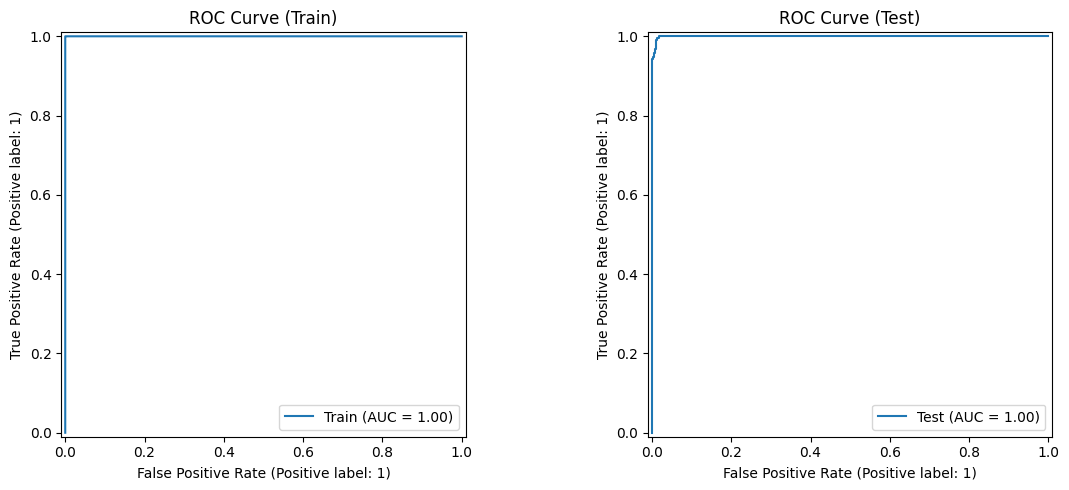

In [21]:
# ROC кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(ada_best, X_train, y_train, ax=ax1, name='Train')
RocCurveDisplay.from_estimator(ada_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('ROC Curve (Train)')
ax2.set_title('ROC Curve (Test)')
plt.tight_layout()
plt.show()

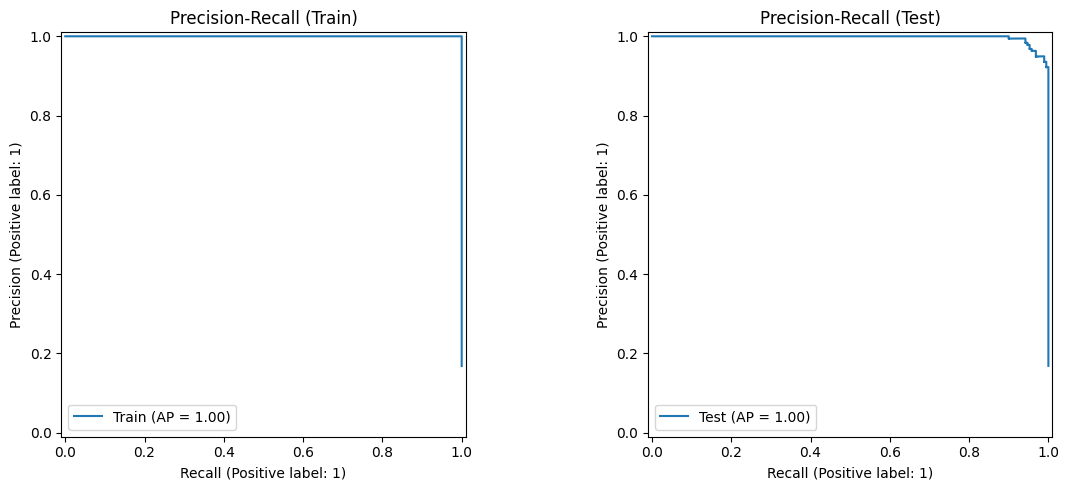

In [22]:
# Precision-Recall кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
PrecisionRecallDisplay.from_estimator(ada_best, X_train, y_train, ax=ax1, name='Train')
PrecisionRecallDisplay.from_estimator(ada_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('Precision-Recall (Train)')
ax2.set_title('Precision-Recall (Test)')
plt.tight_layout()
plt.show()

GradientBoosting

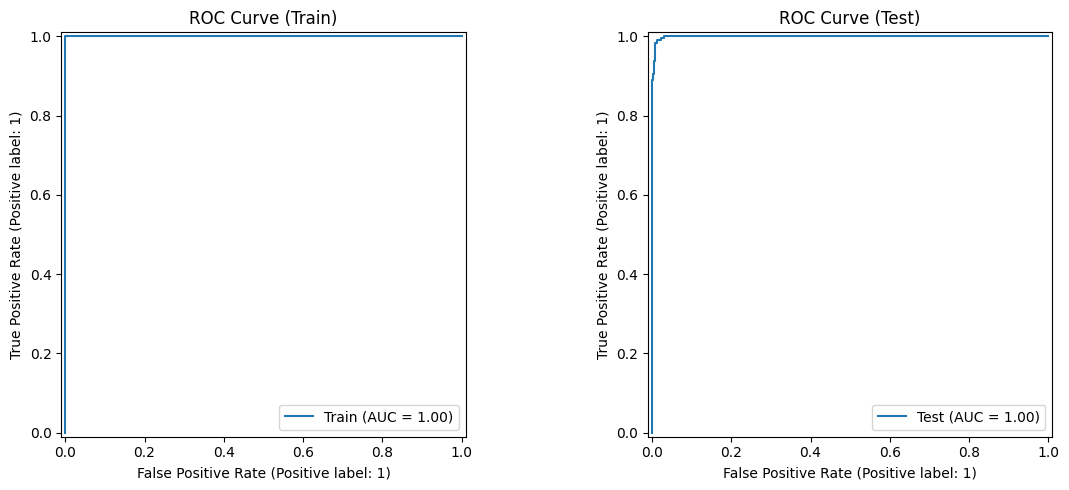

In [23]:
# ROC кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(gb_best, X_train, y_train, ax=ax1, name='Train')
RocCurveDisplay.from_estimator(gb_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('ROC Curve (Train)')
ax2.set_title('ROC Curve (Test)')
plt.tight_layout()
plt.show()

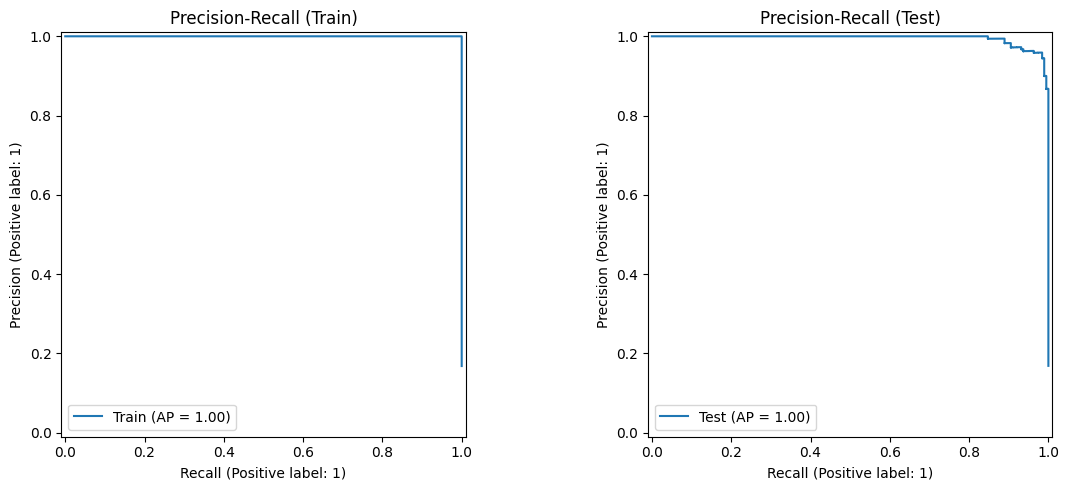

In [24]:
# Precision-Recall кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
PrecisionRecallDisplay.from_estimator(gb_best, X_train, y_train, ax=ax1, name='Train')
PrecisionRecallDisplay.from_estimator(gb_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('Precision-Recall (Train)')
ax2.set_title('Precision-Recall (Test)')
plt.tight_layout()
plt.show()

XGBoost

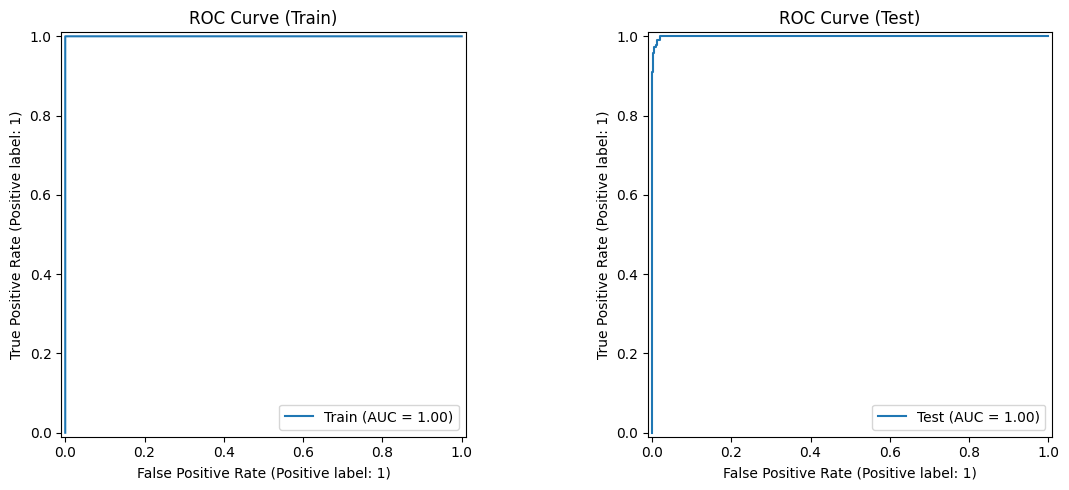

In [25]:
# ROC кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(xgb_best, X_train, y_train, ax=ax1, name='Train')
RocCurveDisplay.from_estimator(xgb_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('ROC Curve (Train)')
ax2.set_title('ROC Curve (Test)')
plt.tight_layout()
plt.show()

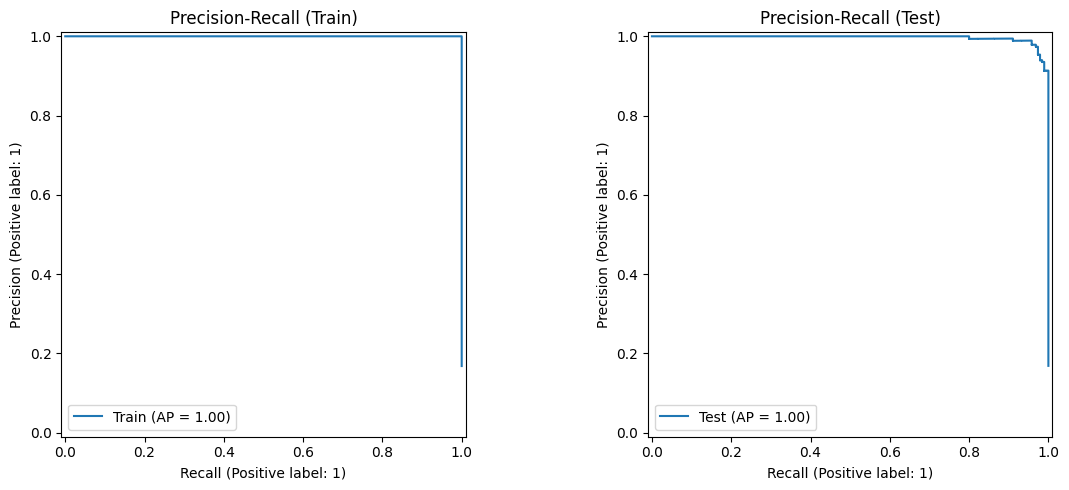

In [26]:
# Precision-Recall кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
PrecisionRecallDisplay.from_estimator(xgb_best, X_train, y_train, ax=ax1, name='Train')
PrecisionRecallDisplay.from_estimator(xgb_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('Precision-Recall (Train)')
ax2.set_title('Precision-Recall (Test)')
plt.tight_layout()
plt.show()

CatBoost

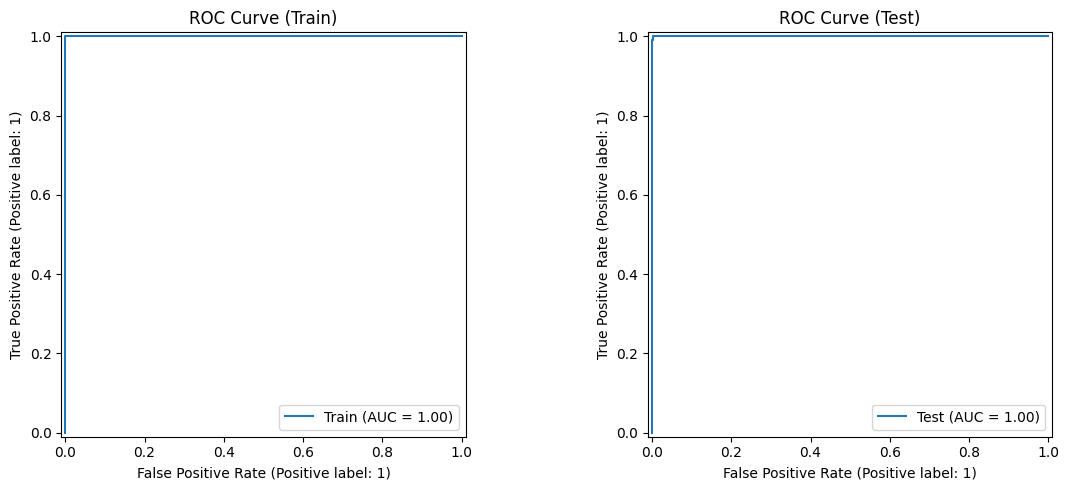

In [27]:
# ROC кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(cat_best, X_train, y_train, ax=ax1, name='Train')
RocCurveDisplay.from_estimator(cat_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('ROC Curve (Train)')
ax2.set_title('ROC Curve (Test)')
plt.tight_layout()
plt.show()

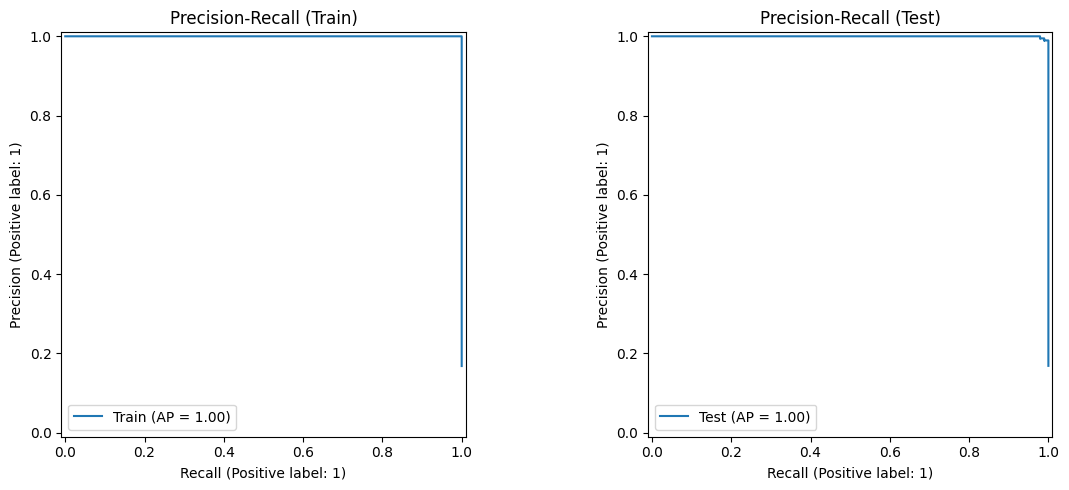

In [28]:
# Precision-Recall кривые
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
PrecisionRecallDisplay.from_estimator(cat_best, X_train, y_train, ax=ax1, name='Train')
PrecisionRecallDisplay.from_estimator(cat_best, X_test, y_test, ax=ax2, name='Test')
ax1.set_title('Precision-Recall (Train)')
ax2.set_title('Precision-Recall (Test)')
plt.tight_layout()
plt.show()

### Вывести метрики на тестовом наборе (как минимум `classification_report`, другие по желанию)

In [29]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

models = {
    'AdaBoost': ada_best,
    'GradientBoosting': gb_best,
    'XGBoost': xgb_best,
    'CatBoost': cat_best
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred))
    
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    })


AdaBoost
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.98      0.95      0.96       190

    accuracy                           0.99      1126
   macro avg       0.98      0.97      0.98      1126
weighted avg       0.99      0.99      0.99      1126


GradientBoosting
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.96      0.96      0.96       190

    accuracy                           0.99      1126
   macro avg       0.98      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126


XGBoost
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       936
           1       0.94      0.98      0.96       190

    accuracy                           0.99      1126
   macro avg       0.97      0.98      0.98      1126
weighted avg       0.99      0.99    

### Сравнить модели, выбрать лучшую

In [30]:
results_df = pd.DataFrame(results)
results_df.sort_values('f1', ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
3,CatBoost,0.996448,0.979381,1.000000,0.989583,0.999966
0,AdaBoost,0.987567,0.978261,0.947368,0.962567,0.999415
1,GradientBoosting,0.986679,0.958115,0.963158,0.960630,0.999010
2,XGBoost,0.985790,0.939394,0.978947,0.958763,0.999314


Наилучшие результаты показала модель CatBoost с метрикой ROC-AUC = 0.999966 и accuracy = 99.64% на тестовой выборке. Она также продемонстрировала идеальный recall (100%), что означает отсутствие ложноотрицательных прогнозов - критически важно для задачи оттока клиентов. Остальные модели также показали высокие результаты: AdaBoost (ROC-AUC = 0.999415), XGBoost (ROC-AUC = 0.999314) и GradientBoosting (ROC-AUC = 0.999010). Все модели имеют F1-меру выше 0.95, что свидетельствует о хорошем балансе между precision и recall (чего и добивались, используя `GridSearchCV`).

**CatBoost** выбран в качестве лучшей модели для дальнейшего анализа SHAP и интерпретации результатов.

In [31]:
best_model = cat_best

## Важность признаков

### С использованием `shap.TreeExplainer` получить $SHAP$-значения для лучшей модели

In [32]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1126, 18)


### Построить график `shap.plots.force` для одного объекта выборки и для среза произвольного размера

force plot для одного объекта

In [33]:
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values[0], X_test.iloc[0])

force plot для среза (50 объектов)

In [34]:
shap.plots.force(explainer.expected_value, shap_values[:50], X_test.iloc[:50])

### Построить график `shap.plots.bar` для одного объекта выборки

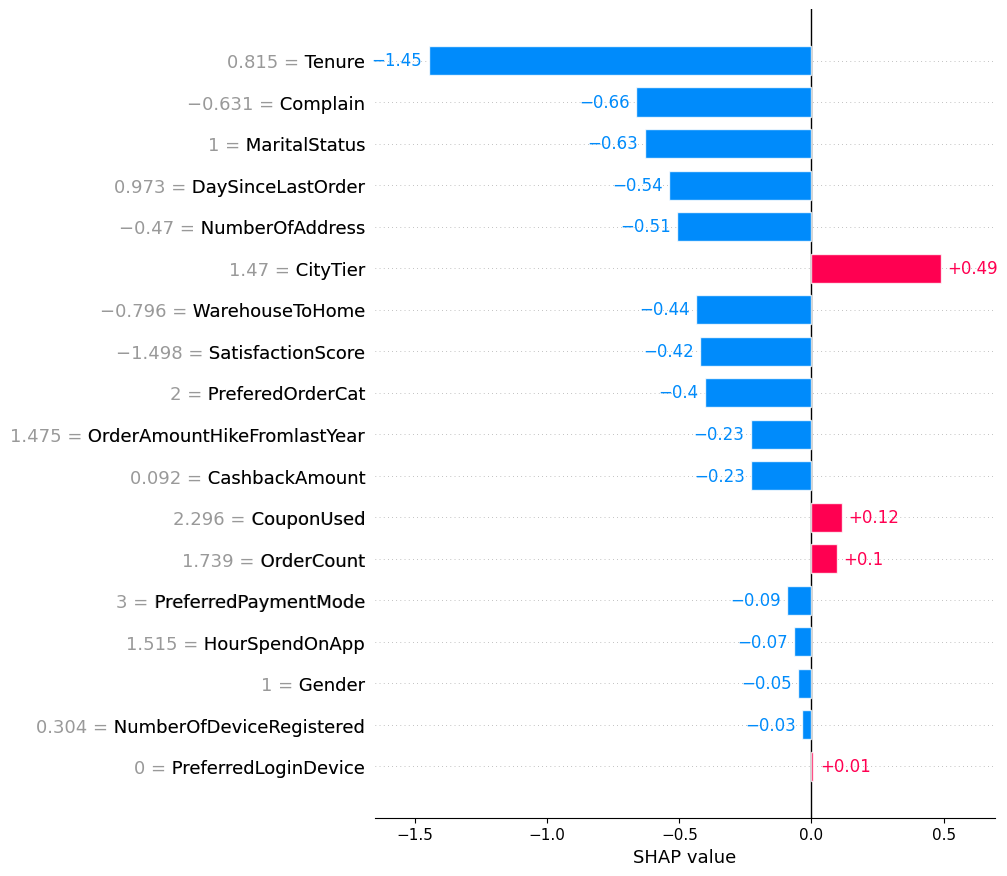

In [35]:
shap_values_test = explainer(X_test)
shap.plots.bar(shap_values_test[0], max_display=X_test.shape[1])

### Построить график `shap.plots.waterfall` для одного объекта выборки

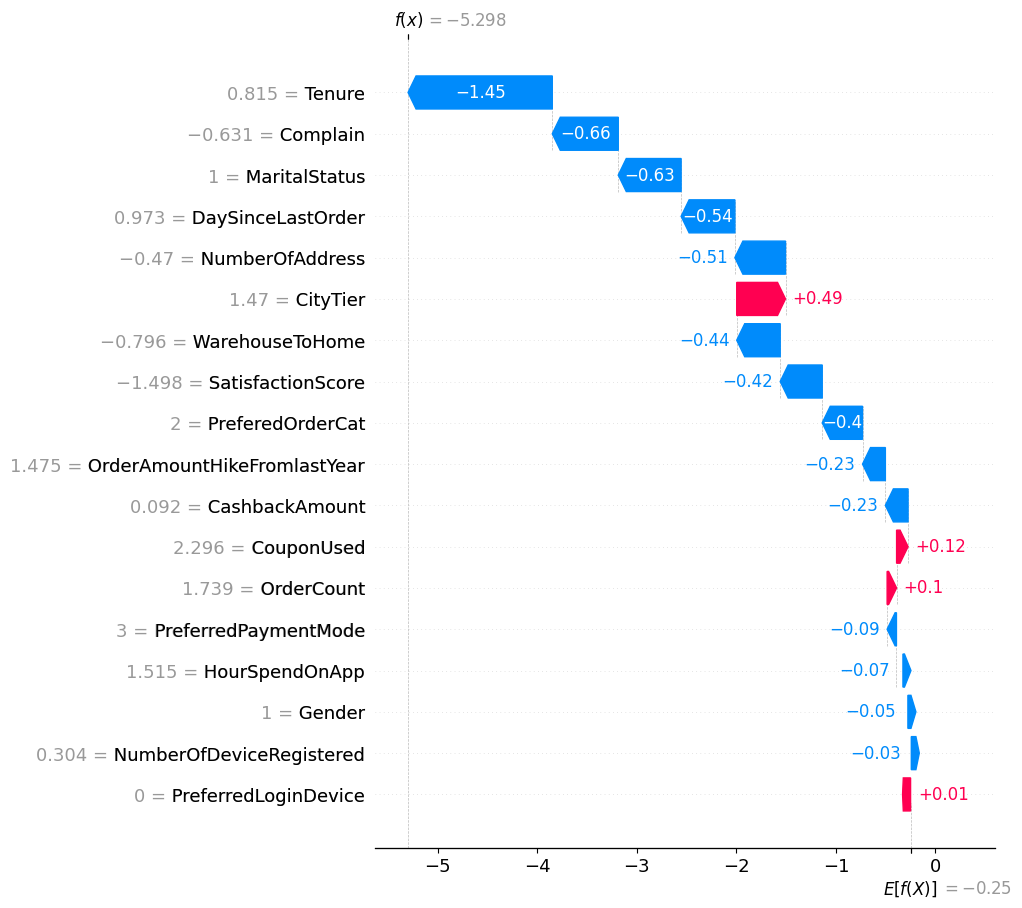

In [36]:
shap.plots.waterfall(shap_values_test[0], max_display=X_test.shape[1])

### Построить 2 графика `shap.plots.scatter` для какого-нибудь признака
На одном раскрасить относительно себя, на втором &ndash; относительно другого признака.

scatter plot для признака CashbackAmount (раскраска относительно себя)

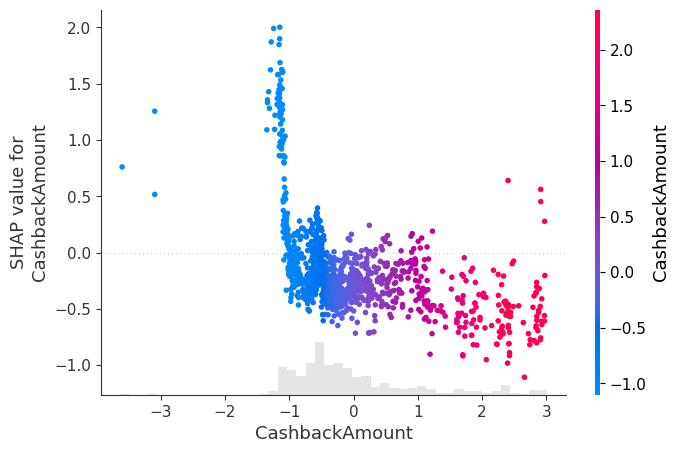

In [37]:
shap.plots.scatter(shap_values_test[:, "CashbackAmount"], color=shap_values_test[:, "CashbackAmount"])

scatter plot для признака CashbackAmount (раскраска относительно Tenure)

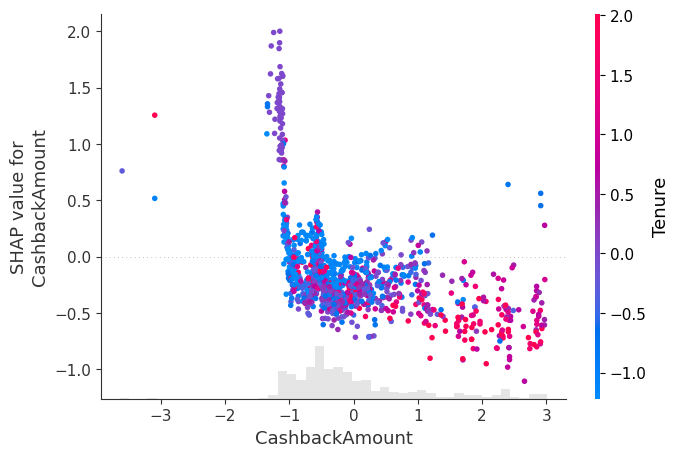

In [38]:
shap.plots.scatter(shap_values_test[:, "CashbackAmount"], color=shap_values_test[:, "Tenure"])

### Построить график `shap.plots.beeswarm` для всех признаков

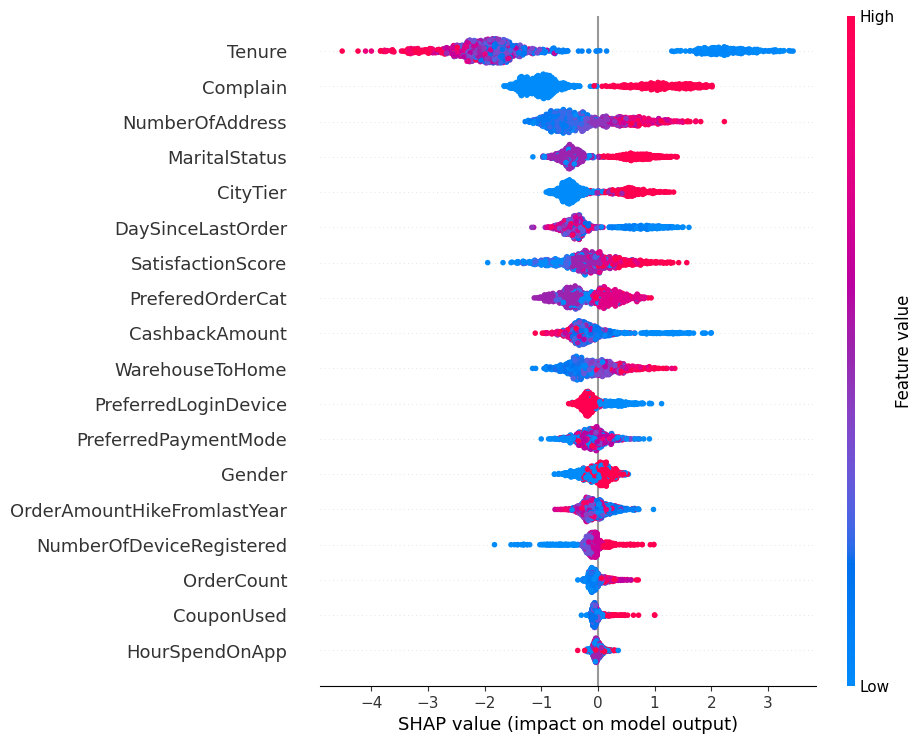

In [39]:
shap.plots.beeswarm(shap_values_test, max_display=X_test.shape[1])

### Построить график `shap.plots.bar` для всех признаков

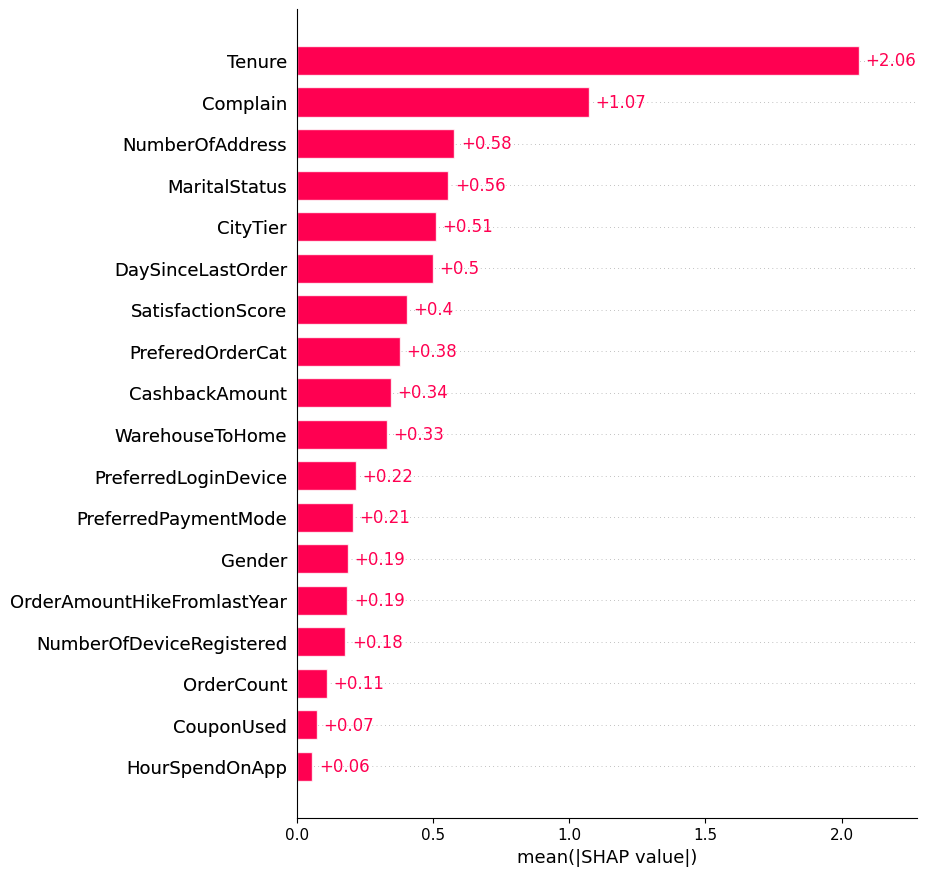

In [40]:
shap.plots.bar(shap_values_test, max_display=X_test.shape[1])

### На основании двух последних графиков и/или используя `feature_importance` отфильтровать признаки (отразить сформулированные выводы в тексте), переобучить лучшую модель

Буду использовать `feature_importance`

In [41]:
importance_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
0,Tenure,15.821654
12,Complain,8.901173
9,SatisfactionScore,8.349714
11,NumberOfAddress,7.533702
3,WarehouseToHome,6.782473
2,CityTier,6.058862
4,PreferredPaymentMode,6.007184
13,OrderAmountHikeFromlastYear,5.875699
10,MaritalStatus,5.753276
16,DaySinceLastOrder,5.501770


Фильтрацию признаков проведем путем отсечения по порогу = 5

In [42]:
filtered_features = importance_df[importance_df['importance'] > 5]
filtered_features

,feature,importance
0,Tenure,15.821654
12,Complain,8.901173
9,SatisfactionScore,8.349714
11,NumberOfAddress,7.533702
3,WarehouseToHome,6.782473
2,CityTier,6.058862
4,PreferredPaymentMode,6.007184
13,OrderAmountHikeFromlastYear,5.875699
10,MaritalStatus,5.753276
16,DaySinceLastOrder,5.501770


Применение фильтрации

In [43]:
X_train_filt = X_train[filtered_features['feature'].tolist()]
X_test_filt = X_test[filtered_features['feature'].tolist()]

Переобучение лучшей модели

In [44]:
model_filtered = best_model.__class__(**best_model.get_params())
model_filtered.fit(X_train_filt, y_train)

CatBoostClassifier(class_weights=[1, np.float64(4.941952506596306)], depth=10, iterations=150, l2_leaf_reg=1, learning_rate=0.2, random_state=42, verbose=0)

### Сравнить метрики до и после фильтрации

In [45]:
y_pred_before = best_model.predict(X_test)
y_proba_before = best_model.predict_proba(X_test)[:, 1]

y_pred_after = model_filtered.predict(X_test_filt)
y_proba_after = model_filtered.predict_proba(X_test_filt)[:, 1]

metrics_comparison = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    'before': [
        accuracy_score(y_test, y_pred_before),
        precision_score(y_test, y_pred_before),
        recall_score(y_test, y_pred_before),
        f1_score(y_test, y_pred_before),
        roc_auc_score(y_test, y_proba_before)
    ],
    'after': [
        accuracy_score(y_test, y_pred_after),
        precision_score(y_test, y_pred_after),
        recall_score(y_test, y_pred_after),
        f1_score(y_test, y_pred_after),
        roc_auc_score(y_test, y_proba_after)
    ],
    'delta': [
        accuracy_score(y_test, y_pred_after) - accuracy_score(y_test, y_pred_before),
        precision_score(y_test, y_pred_after) - precision_score(y_test, y_pred_before),
        recall_score(y_test, y_pred_after) - recall_score(y_test, y_pred_before),
        f1_score(y_test, y_pred_after) - f1_score(y_test, y_pred_before),
        roc_auc_score(y_test, y_proba_after) - roc_auc_score(y_test, y_proba_before)
    ]
})

metrics_comparison

,metric,before,after,delta
0,accuracy,0.996448,0.996448,0.000000
1,precision,0.979381,0.979381,0.000000
2,recall,1.000000,1.000000,0.000000
3,f1,0.989583,0.989583,0.000000
4,roc_auc,0.999966,0.999904,-0.000062


После отбора признаков метрики остались практически неизменными: accuracy (0.9964), precision (0.9794), recall (1.0) и F1-мера (0.9896) не изменились, а ROC-AUC снизился незначительно (с 0.999966 до 0.999904). Это свидетельствует о том, что отброшенные признаки были избыточными и не несли полезной информации для прогнозирования оттока. Таким образом, удалось сократить количество признаков с 18 до 11 без потери качества модели, что упрощает интерпретацию результатов и снижает риск переобучения.

### Визуализировать полученное дерево решений

Визуализирую первое дерево из ансамбля лучшей модели

In [46]:
best_model.plot_tree(tree_idx=0)

## Регрессия

Для чистоты эксперемента поменяем целевой признак с `Churn` на `CashbackAmount`

In [47]:
y_reg = df_reg['CashbackAmount']
X_reg = df_reg.drop(columns='CashbackAmount')

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, stratify=y, random_state=42
)

### С использованием `GridSearchCV`/`grid_search` осуществить подбор гиперпараметра модели линейной регрессии с использованием $XGBoost$ или $CatBoost$
> [xgboost.XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor) в $XGBoost$, [CatBoostRegressor](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor) в $CatBoost$.

In [48]:
from xgboost import XGBRegressor

xgb_regressor = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_reg_grid = GridSearchCV(xgb_regressor, xgb_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_reg_grid.fit(X_train_reg, y_train_reg)
xgb_reg_best = xgb_reg_grid.best_estimator_
print("XGBoost Regressor best params:", xgb_reg_grid.best_params_)

XGBoost Regressor best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'reg_alpha': 0.1, 'reg_lambda': 5}


### Вывести метрики $MSE$, $MAE$ и $R^2$ на тестовом наборе

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

y_reg_pred = xgb_reg_best.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_reg_pred)
mae = mean_absolute_error(y_test_reg, y_reg_pred)
r2 = r2_score(y_test_reg, y_reg_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 148.0531
MAE: 5.1787
R²: 0.9399


### Осуществить фильтрацию признаков по аналогии с пунктом 4

In [50]:
importance_reg_df = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': xgb_reg_best.feature_importances_
}).sort_values('importance', ascending=False)
importance_reg_df

,feature,importance
8,PreferedOrderCat,0.898482
15,OrderCount,0.025616
6,HourSpendOnApp,0.022451
16,DaySinceLastOrder,0.007811
7,NumberOfDeviceRegistered,0.006991
14,CouponUsed,0.006121
13,OrderAmountHikeFromlastYear,0.004549
11,NumberOfAddress,0.004106
2,CityTier,0.003716
4,PreferredPaymentMode,0.003252


In [51]:
filtered_features = importance_reg_df[importance_reg_df['importance'] > 0.002]
filtered_features

,feature,importance
8,PreferedOrderCat,0.898482
15,OrderCount,0.025616
6,HourSpendOnApp,0.022451
16,DaySinceLastOrder,0.007811
7,NumberOfDeviceRegistered,0.006991
14,CouponUsed,0.006121
13,OrderAmountHikeFromlastYear,0.004549
11,NumberOfAddress,0.004106
2,CityTier,0.003716
4,PreferredPaymentMode,0.003252


In [52]:
X_train_reg_filt = X_train_reg[filtered_features['feature'].tolist()]
X_test_reg_filt = X_test_reg[filtered_features['feature'].tolist()]

### Переобучить модель на отфильтрованном наборе признаков

In [53]:
xgb_reg_best_filtered = XGBRegressor(
    **xgb_reg_grid.best_params_,
    random_state=42,
    eval_metric='rmse'
)
xgb_reg_best_filtered.fit(X_train_reg_filt, y_train_reg)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

### Сравнить метрики до и после фильтрации

In [54]:
y_reg_pred = xgb_reg_best.predict(X_test_reg)
y_reg_pred_filtered = xgb_reg_best_filtered.predict(X_test_reg_filt)

metrics = {
    'Model': ['XGB Regressor (all features)', 'XGB Regressor (filtered)'],
    'MSE': [
        mean_squared_error(y_test_reg, y_reg_pred),
        mean_squared_error(y_test_reg, y_reg_pred_filtered)
    ],
    'MAE': [
        mean_absolute_error(y_test_reg, y_reg_pred),
        mean_absolute_error(y_test_reg, y_reg_pred_filtered)
    ],
    'R²': [
        r2_score(y_test_reg, y_reg_pred),
        r2_score(y_test_reg, y_reg_pred_filtered)
    ],
    'RMSE': [
        root_mean_squared_error(y_test_reg, y_reg_pred),
        root_mean_squared_error(y_test_reg, y_reg_pred_filtered)
    ]
}

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,MSE,MAE,R²,RMSE
0,XGB Regressor (all features),148.053100,5.178684,0.939919,12.167707
1,XGB Regressor (filtered),144.953139,5.180194,0.941177,12.039649


После фильтрации признаков модель показала улучшение по всем ключевым метрикам: MSE снизился на 2.1%, R² вырос до 0.9412, RMSE уменьшился на 1.1%. При этом количество признаков сократилось с 17 до 14. Это подтверждает, что отбор признаков позволил устранить шум и улучшить обобщающую способность модели.